<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 2.3 (Nonlinear Features) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Learning Outcomes](#Learning-Outcomes)

2.  [Introduction](#Introduction)

3.  [Import Python Libraries](#Import-Python-Libraries)

4.  [Define Useful Functions](#Define-Useful-Functions)

5.  [Load The First Dataset](#Load-The-First-Dataset)

6.  [Least Squares Linear Regression](#Least-Squares-Linear-Regression)

7.  [Implementing Least Squares Linear Regression](#Implementing-LSLR)

8.  [Introducing The Sklearn LinearRegression Function](#Introducing-Sklearn-LinearRegression)

9.  [A New Dataset: Now With Initial Velocity](#Initial-Velocity-Dataset)

10. [Multivariate Linear Regression](#Multivariate-Linear-Regression)

11. [Multiple Target Multivariate Linear Regression](#Multiple-Targets)

12. [Lesson Summary](#Lesson-Summary)

13. [Appendix A: New Term Definitions](#Appendix-Definitions)

14. [Appendix B: Derivation Of Least Squares Linear Regression](#Appendix-LSLR-Derivation)
$
\newcommand{\parens}[1]{\left( #1 \right)}
\newcommand{\brackets}[1]{\left[ #1 \right]}
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
\newcommand{\twomatrixtall}[2]{
\left( \begin{array}{c} #1 \\ #2 \end{array} \right)
}
\newcommand{\threematrixtall}[3]{
\left( \begin{array}{c} #1 \\ #2 \\ #3 \end{array} \right)
}
\newcommand{\fourmatrixsquare}[4]{
\left( \begin{array}{c c} #1 & #2 \\ #3 & #4 \end{array} \right)
}
\newcommand{\fourmatrixlong}[4]{
\left( \begin{array}{c c c c} #1 & #2 & #3 & #4 \end{array} \right)
}
\newcommand{\ninematrixsquare}[9]{
\left( \begin{array}{c c c} #1 & #2 & #3 \\ #4 & #5 & #6 \\ #7 & #8 & #9 \end{array} \right)
}
$

<a name="Learning-Outcomes"></a>

---

<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  1.

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

<font size = 6> <b> 2. Introduction </b> </font>

---

<font size = 5> <b> 2.1 Linear Models </b> </font>

So far in this module, we've learned how to build linear models to describe physical systems. As we saw, in a linear model, we predict a target variable using a linear combination of one or more feature variables. For example, when modeling a free-falling object, we used the feature variable `Time (s)` to predict the target variable `Speed (m/s)`:

<br>

<center>
<font size = 5>
 $v\of{t} = c \spc t + b$
</font>
</center>

  <br>

  * $\large c$ is the linear coefficient, which tells us how speed changes with time.

  <br>

  * $\large b$ is the bias, which gives the object's speed at time ($\large t = 0$).

<br>

We also learned how to use least squares linear regression to compute the values for $\large c$ and $\large b$ that produced the best-fit model which minimized the loss over the dataset.

<br>

Finally, we explored more advanced scenarios involving multi-target, multivariate linear models when our system has multiple target and feature variables. In those cases, we saw that we can express our model's predictions as a vector sum of matrix-like linear coefficients multiplied by vector-like feature variables. If our model has ($\large N$) features and ($\large M$) targets then:

<br>

<center>
<font size = 5>
 $\hat{y} = \lsum \hspace{0.1 pc}
  \ninematrixsquare{c_{i,11}}{...}{c_{i,1M}}{...}{...}{...}{c_{i,M1}}{...}{c_{i,MM}} \spc \threematrixtall{X_{i,1}}{...}{X_{i,M}} + \threematrixtall{b_1}{...}{b_M}$
</font>
</center>

<br>

The example we used was two-dimensional, perfectly inelastic collisions between two objects. In that case, our model became:

<br>

<center>
<font size = 5>
 $\twomatrixtall{v_{f,x}}{v_{f,y}} = \fourmatrixsquare{c_1}{0}{0}{c_1} \spc
  \twomatrixtall{v_{1,x}}{v_{1,y}} + \fourmatrixsquare{c_2}{0}{0}{c_2} \spc
  \twomatrixtall{v_{2,x}}{v_{2,y}} + \twomatrixtall{0}{0}$
</font>
</center>

<br>

<br>

<center>
<font size = 5>
$c_1 = \dpfrac{m_1}{m_1 + m_2} \textrm{,} \hspace{2 pc}
 c_2 = \dpfrac{m_2}{m_1 + m_2}$
</font>
</center>

<center>$\rule$</center>

<font size = 5> <b> 2.2 Moving Beyond Linear Models </b> </font>

Consider again the case of a free-falling object. But instead of modeling the object's speed, this time we're interested in modeling the object's position as a function of time. From introductory physics, we know that the position $\large h\of{t}$ of an object in free-fall is given by:

<br>

<center>
<font size = 5>
 $h\of{t} = c_1 \spc t + c_2 \spc t^2 + b$
</font>
</center>

<br>

This formula is clearly not a linear function of time. No straight-line model will capture the curved nature of this relationship, which means that simple linear regression won't work to help us find the best-fit parameters. One possible solution to this problem would be to invent a completely new regression algorithm just for quadratic relationships. But what if we later needed a cubic model? Or models needing even higher order terms? We'd need a different algorithm for each case! Fortunately, there's a much better approach.

<center>$\rule$</center>

<font size = 5> <b> 2.3 Linearization </b> </font>

It turns out we can still use linear regression to model curved relationships ... by transforming our features. This method is called [linearization](#Definition-Linearization), and it's a powerful technique widely used in real-world science and engineering.

Now, this is going to seem like a trick, but this is really what's done in the real-world and it works very well. We treat the squared feature term like a completely different feature, unrelated to the linear feature term. Now, we have two "independent" linear features, the first one is 'time' and the second is 'time-squared'. The great part is that we already know how to solve this new problem, using multivariate linear regression.

<br>

<center>
<font size = 5>
 $h\of{t} = c_1 \spc A + c_2 \spc B + b$
</font>
</center>

  <br>

  * $\large A = t$ is the linear feature

  <br>

  * $\large B = t^2$ is the quadratic feature

<br>

Even though the output is curved, this is still a linear model in the transformed feature space. This idea is the foundation of a broad class of techniques known as [feature engineering](#Definition-Feature-Engineering). By adding nonlinear transformations (like powers, roots, trigonometric functions, etc.) as new features, linearization lets us model a wide range of nonlinear behavior using the familiar tools of linear regression.

<br>

In this lesson, we explore this method by:

  * Building a linear regression model for a dataset where the output is nonlinear.

  * Extending our feature set by adding polynomial terms.

  * Using scikit-learn to fit both models and compare their performance.

By the end, we see how powerful and flexible linear models can become when we engineer the right features.

[Return to Top](#Notebook-Start)

<a name="Import-Python-Libraries"></a>

---

<font size = 6> <b> 3. Import Python Libraries </b> </font>

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display_html
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

[Return to Top](#Notebook-Start)

<a name="Define-Useful-Functions"></a>

---

<font size = 6> <b> 4. Define Useful Functions </b> </font>

---

In [ ]:
#@title This cell defines several useful functions that are used throughout the notebook.

##=============================================================================================##
## Included Functions:                                                                         ##
##                                                                                             ##
## 1. display_dataframes - Display multiple DataFrames side-by-side with titles                ##
## 2. load_model         - Load and clean data from input file, split into feature and target  ##
## 3. display_models      - Display models' parameters and loss in a DataFrame                 ##
## 4. plot_data          - Create a graph with raw data, can add model to graph if needed      ##
##=============================================================================================##

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  dataframe_list - List of DataFrames to be displayed                              ##
##            title_list     - List of titles for the displayed DataFrames                     ##
##            n_items        - Number of items to display (optional, default = 5)              ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(dataframe_list, title_list, n_items = 5):

  ##===========================================================================================##
  ## Create a String for Housing the Commands to Be Sent to the display_html() Function:       ##
  ##===========================================================================================##

  html_str = ""

  ##===========================================================================================##
  ## Loop Over the Elements in the item_list and title_list:                                   ##
  ##===========================================================================================##

  for df, title in zip(dataframe_list, title_list):

    # Convert the current dataframe info to html:

    html_df = df.head(n_items).to_html()

    ##=========================================================================================##
    ## Wrap title and DataFrames in a Styled HTML <div>:                                       ##
    ##=========================================================================================##

    html_str += "<div style='display: inline-block; margin-right: 20px; vertical-align: top;'>"

    html_str += "<h3 style='text-align: center;'>" + str(title) + "</h3><hr>" + str(html_df)

    html_str += "</div>"

  ##===========================================================================================##
  ## Send the HTML String to the display_html() Function:                                      ##
  ##===========================================================================================##

  display_html(html_str, raw = True)

##=============================================================================================##
## Function:  load_model                                                                       ##
##                                                                                             ##
## Purpose:   Load and clean data from input file, split into feature and target               ##
##                                                                                             ##
## Input(s):  filename     - Name of the file containing the data                              ##
##            feature_list - List of column names containing feature data                      ##
##            target_list  - List of column names containing target data                       ##
##                                                                                             ##
## Output(s): features     - DataFrame containing model feature data                           ##
##            targets      - DataFrame containint model target data                            ##
##=============================================================================================##

def load_model(filename, feature_list, target_list):

  ##===========================================================================================##
  ## Load in the Full Data Set and Drop Any Rows Missing Data:                                 ##
  ##===========================================================================================##

  data = pd.read_csv(filename).dropna()

  ##===========================================================================================##
  ## Separate the Feature and Target Data and Drop Any Rows Missing Data:                      ##
  ##===========================================================================================##

  # Identify the feature data:

  features = pd.DataFrame(data[feature_list])

  # Identify the target data:

  targets = pd.DataFrame(data[target_list])

  # Display the feature and target data:

  display_dataframes([data, features, targets], ["Full Dataset", "Feature Data", "Target Data"])

  ##===========================================================================================##
  ## Return the Feature Data, and Target Data:                                                 ##
  ##===========================================================================================##

  return features, targets

##=============================================================================================##
## Function:  display_models                                                                   ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##            coef_list  - List of models' coefficients to be displayed                        ##
##            bias_list  - List of models' bias to be displayed                                ##
##            loss_list  - List of models' loss to be displayed                                ##
##            title      - Title for the display of models                                     ##
##            trunc      - Number of decimals to display for numbers (optional, default = 3)   ##
##            n_items    - Number of items to display (optional, default = 5)                  ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_model(model_list, coef_list, bias_list, loss_list, title, trunc = 3, n_items = 5):

  ##===========================================================================================##
  ## Round the Numeric Values to the Desired Level of Desired Truncation:                      ##
  ##===========================================================================================##

  for i in range (0, len(model_list)):

    coef_list[i] = np.round(coef_list[i], trunc)
    bias_list[i] = np.round(bias_list[i], trunc)
    loss_list[i] = np.round(loss_list[i], trunc)

  ##===========================================================================================##
  ## Create a DataFrame to Hold the Results:                                                   ##
  ##===========================================================================================##

  results = pd.DataFrame()

  ##===========================================================================================##
  ## Add the Contents of the DataFrame Columns:                                                ##
  ##===========================================================================================##

  # Add the model names:

  results["Model"] = model_list

  # Add the model coefficients:

  results["Coefficient(s)"] = coef_list

  # Add the model biases:

  results["Bias"] = bias_list

  # Add the model rmses:

  results["Loss"] = loss_list

  ##===========================================================================================##
  ## Index the Results DataFrame By Model Name:                                                ##
  ##===========================================================================================##

  results.set_index("Model", inplace = True)

  ##===========================================================================================##
  ## Display the Results DataFrame Using display_dataframes():                                 ##
  ##===========================================================================================##

  display_dataframes([results], [title], n_items)

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Purpose:   Create a scatterplot with optional model overlays and error bands                ##
##                                                                                             ##
## Input(s):  x_data        - List of data points' x-axis values                               ##
##            y_data        - List of data points' y-axis values                               ##
##            title         - Graph title                                                      ##
##            axis_labels   - Override axis labels [x_label, y_label] (optional)               ##
##            model_list    - List of model predictions to overlay (optional)                  ##
##            color_list    - Colors for each model line (optional)                            ##
##            label_list    - Labels for each model line (optional)                            ##
##            error_display - Show +/- error band around first model (default is False)        ##
##            error         - Error value for shaded band (optional)                           ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(x_data, y_data, title, axis_labels = [], model_list = [], color_list = [],
              label_list = [], error_display = False, error = 0):

  ##===========================================================================================##
  ## Setup the Graph:                                                                          ##
  ##===========================================================================================##

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (12, 9))

  # Add a graph to the figure:

  graph = figure.add_subplot()

  # Set the graph background Color:

  graph.set_facecolor('lightcyan')

  # Set the graph title:

  graph.set_title(title, fontsize = 20)

  # Set the x_label and y_label:

  if (axis_labels != []):

    graph.set_xlabel(axis_labels[0], fontsize = 14)

    graph.set_ylabel(axis_labels[1], fontsize = 14)

  # Apply a grid to the graph:

  graph.grid(which = 'both')

  # Adjust the x-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'x', tight = False)

  # Adjust the y-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'y', tight = False)

  ##===========================================================================================##
  ## Add Data to the Graph:                                                                    ##
  ##===========================================================================================##

  # Create a scatterplot of the data:

  sns.scatterplot(x = x_data, y = y_data, ax = graph)

  # Overlay model predictions:

  for i in range(0, len(model_list)):

    graph.plot(model_list[i]["Target"], model_list[i]["Predictions"], color = color_list[i],
               label = label_list[i])

  ##===========================================================================================##
  ## If requested, show the +/- error bounds:                                                  ##
  ##===========================================================================================##

  if ((error_display == True) and model_list != []):

    # Create the error+ model:

    model_plus_error  = model_list[-1]["Predictions"] + error

    # Create the error- model:

    model_minus_error = model_list[-1]["Predictions"] - error

    # Store the error+ and error- models in a DataFrame and Sort by x_data values:

    error_df = pd.DataFrame({
        'X-Data': model_list[0]["Target"],
        'Model+Error': model_plus_error,
        'Model-Error': model_minus_error
    }).sort_values(by = "X-Data")

    # Use graph.fill to highlight the region between the error+ and error- models:

    graph.fill_between(error_df['X-Data'], error_df['Model+Error'], error_df['Model-Error'],
                       alpha = 0.5, color = (0.6, 0.6, 0.6), label = "Error Bounds")

  ##===========================================================================================##
  ## Apply the Legend and Return the graph Object:                                             ##
  ##===========================================================================================##

  # Add the graph legend:

  if (label_list != []): graph.legend()

  # Return the graph:

  return graph

[Return to Top](#Notebook-Start)

<a name="Load-The-First-Dataset"></a>

---

<font size = 6> <b> 5. Load The First Dataset </b> </font>

---

<font size = 5> <b> 5.1 What Kind Of Data Are We Using? </b> </font>

We'll begin with the same synthetic dataset of a falling object that we used in the previous lesson. Recall that this dataset includes two key simplifications:

  <br>

  1. The object is falling <b>without air resistance</b>.

  <br>

  2. The object starts with <b>zero initial speed</b>.

  <br>

These simplifications were made to allow us to focus on introducing the modeling process without needing to deal with extra complications.

<center>$\rule$</center>

<font size = 5> <b> 5.2 What's In The Dataset? </b> </font>

Each row in the dataset represents a single measurement taken during the object's fall and includes:

  <br>

  * <b>Time (s)</b>: How many seconds have passed since the object started falling

  <br>

  * <b>Speed (m/s)</b>: The object's speed at the moment of measurement, in meters per second

<center>$\rule$</center>

<font size = 5> <b> 5.3 Why This Dataset? </b> </font>

We're starting with this dataset to build on what we learned in the previous lesson. It's simple, clean, and easy to interpret, and we can compare our results with what we got last time.

In [ ]:
##=============================================================================================##
## Load in the Data Set:                                                                       ##
##=============================================================================================##

# Set the data filename:

filename = "freefall_data_1.csv"

# Set the feature list:

feature_list = ["Time (s)"]

# Set the target list:

target_list = ["Position (m)"]

# Load in the data:

features, target = load_model(filename, feature_list, target_list)

Full Dataset 
 
 
 
 Time (s) 
 Speed (m/s) 
 Position (m) 
 
 
 
 
 0 
 0.0202 
 0.2118 
 -0.0112 
 
 
 1 
 0.0221 
 0.2159 
 -0.0032 
 
 
 2 
 0.0278 
 0.2953 
 -0.0187 
 
 
 3 
 0.0368 
 0.2862 
 -0.0814 
 
 
 4 
 0.0618 
 0.6551 
 -0.0298 
 
 
 Feature Data 
 
 
 
 Time (s) 
 
 
 
 
 0 
 0.0202 
 
 
 1 
 0.0221 
 
 
 2 
 0.0278 
 
 
 3 
 0.0368 
 
 
 4 
 0.0618 
 
 
 Target Data 
 
 
 
 Position (m) 
 
 
 
 
 0 
 -0.0112 
 
 
 1 
 -0.0032 
 
 
 2 
 -0.0187 
 
 
 3 
 -0.0814 
 
 
 4 
 -0.0298

<center>$\rule$</center>

<font size = 5> <b> 5.4 Visualize The First Dataset </b> </font>

We create a scatterplot to help us visualize the dataset to remind ourselves of the patterns and relationships between variables. In our scatterplot:

  <br>

  * The x-axis data will be : <b>Time (s)</b>

  <br>

  * The y-axis data will be: <b>Speed (m/s)</b>

  <br>

><b>Note</b>: Each point on the graph shows the speed of the object at a specific moment during its fall.

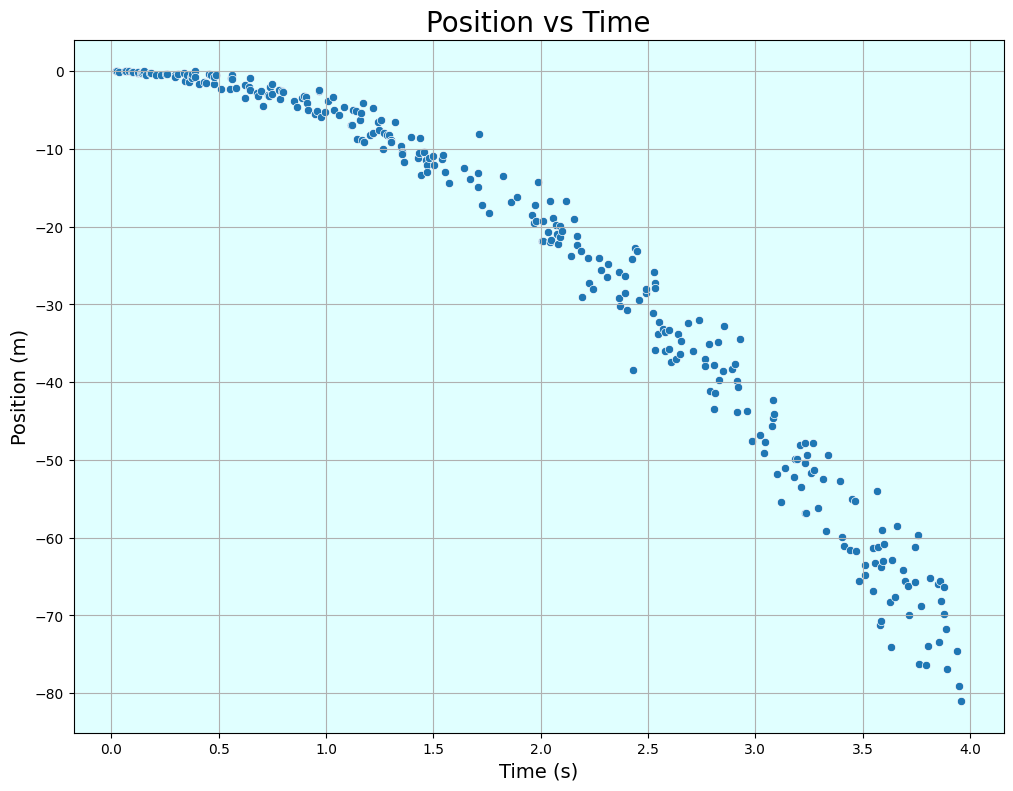

In [ ]:
##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Position vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Position (m)"

# Create a scatterplot of the feature data vs the target data:

graph_1 = plot_data(features[x_label], target[y_label], title, [x_label, y_label])

In the plot above, we see a strong inverse correlation. As the engine
power grows, the gas milage decreases. This makes intuitive sense because an engine which is more powerful will tend to be part of a larger
vehicle. And since larger vehicles have more mass to move around, we
expect them to be less fuel efficient. Furthermore, we can see from this graph that the relationship between horse power and gas milage is noticeably nonlinear.

[Return to Top](#Notebook-Start)

In [ ]:
##=============================================================================================##
## Function:  create_model                                                                     ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def create_model(X, y, name, bias_on = True):

  ##===========================================================================================##
  ## Use a LinearRegression Object to Find the Best Fit for the Model:                         ##
  ##===========================================================================================##

  # Create a LinearRegression object with a forced-origin intercept:

  model = LinearRegression(fit_intercept = bias_on)

  # Fit the LinearRegression objects to the features and target:

  model.fit(X, y)

  # Get the coefficient and bias for the model:

  coefs = np.round(model.coef_[0], 2)
  bias  = np.round(model.intercept_, 2)

  ##===========================================================================================##
  ## Get The Model Predictions:                                                                ##
  ##===========================================================================================##

  predictions = model.predict(X)

  ##===========================================================================================##
  ## Calculate Model Losses:                                                                   ##
  ##===========================================================================================##

  loss = np.sqrt(mean_squared_error(y, predictions))

  ##===========================================================================================##
  ## Create a DataFrame to Store the Model's Results and Predictions:                          ##
  ##===========================================================================================##

  # Create the results DataFrame:

  results_df = pd.DataFrame({"Name": name, "Coefs": [coefs], "Bias": bias, "Loss": loss})

  # Create the predictions DataFrame:

  predictions_df = pd.DataFrame({"Target": X.iloc[:, 0]})

  predictions_df["Predictions"] = predictions

  ##===========================================================================================##
  ## Return the Model's Results and Predictions:                                               ##
  ##===========================================================================================##

  return results_df, predictions_df

<a name="Linear-Model"></a>

---

<font size = 6> Linear Model </font>

---

Let's start with a linear model to relate the gas milage to horsepower and see how it does matching the data.

,Coefficient(s),Bias,Loss
Model,,,
Linear,[-19.33],12.34,6.385


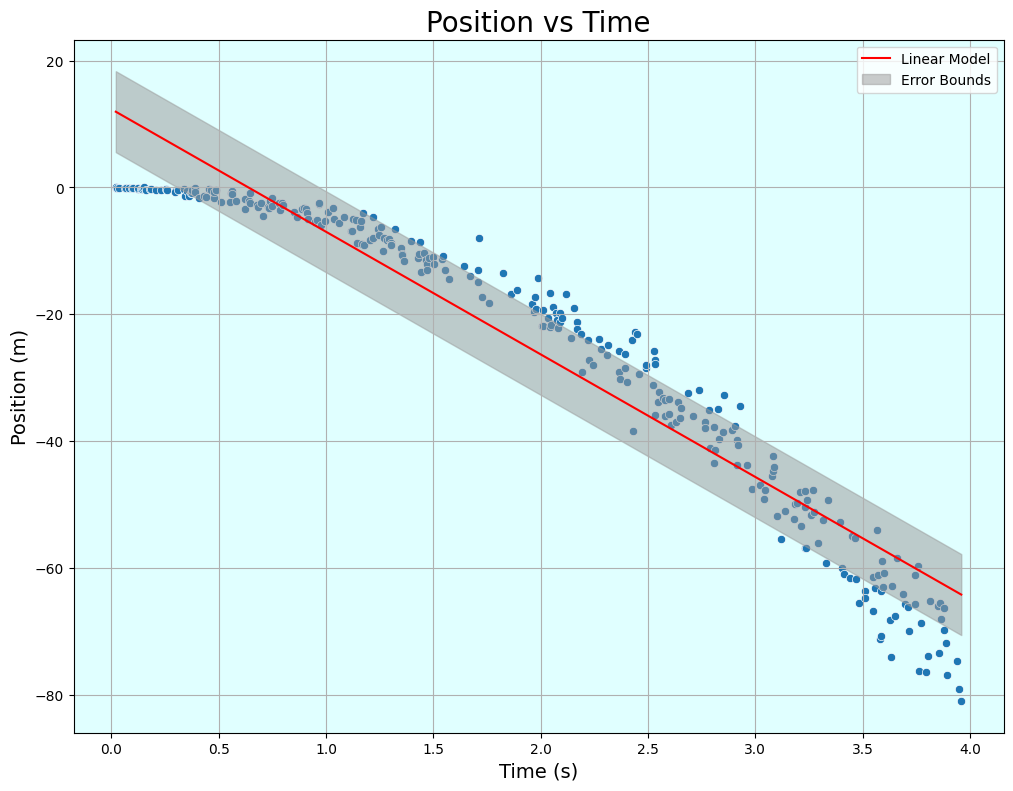

In [ ]:
##=============================================================================================##
## Set the Model Feature(s) and Target:                                                        ##
##=============================================================================================##

X = features.copy()
y = target.copy()

##=============================================================================================##
## Create the Model and Get the Results and Predictions:                                       ##
##=============================================================================================##

linear_results, linear_predictions = create_model(X, y, "Linear")

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

name_list = [linear_results["Name"][0]]

# Set the coefficient(s) list:

coef_list = [linear_results["Coefs"][0]]

# Set the bias list:

bias_list = [linear_results["Bias"][0]]

# Set the loss list:

loss_list = [linear_results["Loss"][0]]

# Display the results:

display_model(name_list, coef_list, bias_list, loss_list, "Models")

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Position vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Position (m)"

# Create the model, color, and label lists:

model_list = [linear_predictions]
color_list = ["red"]
label_list = ["Linear Model"]

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X[x_label], y[y_label], title, [x_label, y_label], model_list, color_list,
                  label_list, error_display = True, error = loss_list[-1])

We can see from the above, that the linear model has a root mean squared error of 4.893. We can also see that this model fails to capture the shape of the relationship between the fuel efficiency and the engine power. The shape of the relationship, it feels sort of arcing or curved. But because we're using simple linear regression here, we can't possibly get that curvy shape. With what we know so far, it seems impossible to capture this nonlinear relationship between the miles per gallon and our horsepower.

[Return to Top](#Notebook-Start)

<a name="Quadratic-Model"></a>

---

<font size = 6> Quadratic Model </font>

---

Naturally, a simple linear regression model could never produce a curved line because simple linear regression models do not have higher order terms.

<br>

Suppose we wanted to generalize our idea of a model with squared features. One possible approach would be to create a new type of model; a squared regression model. In such a model, predictions would be the weighted sum of the features, plus the weighted sum of the features squared, plus an intercept term.

<br>

<center>
<font size = 5>
 $Y = \displaystyle \Sigma^N_{i=1} \hspace{0.1 pc} n_i \hspace{0.1 pc} X^2_i + m_i \hspace{0.1 pc} X_i + b$
</font>
</center>

<br>

It turns out there's a much simpler solution where we can still use the same structure that we developed for linear regression models and the same scikitlearn library but get nonlinear behavior.

<br>

Now, this is going to seem like a trick, but this is really what's done in the
real-world and it works very well. All we do is add a squared feature to our
model. We will first compute the square of the data in the `horsepower` column. Then we will assign these squared values to a new column with name `hp2`. Now, we can use a multilinear approach to modelling the data, where the squared data becomes a new 'linear dimension'.

<br>

To build our quadratic model, we will first need to create values which are the square of the data in the `horsepower` column.  We will assign these squared values to a new column with name `hp2`.

Now, we can use a multilinear approach to modelling the data, where the squared data becomes a new 'linear dimension'.

,Coefficient(s),Bias,Loss
Model,,,
Linear,[-19.33],12.34,6.385
Quadratic,"[-0.12, -4.85]",0.00,2.835


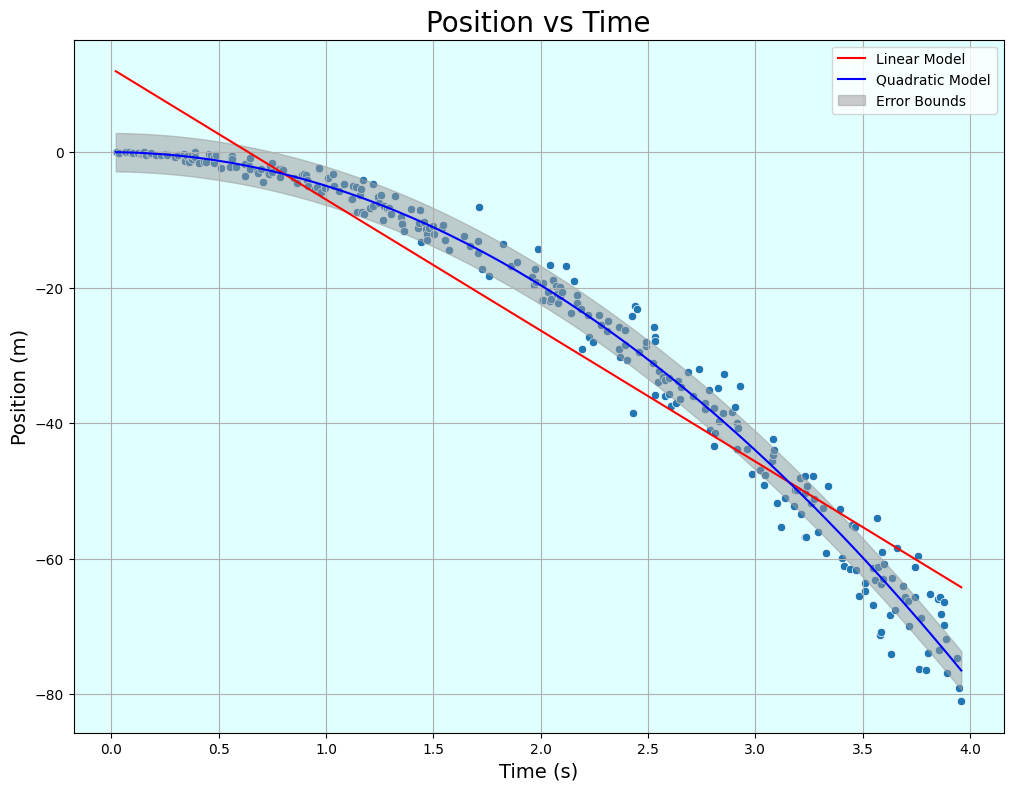

In [ ]:
##=============================================================================================##
## Set the Model Feature(s) and Target:                                                        ##
##=============================================================================================##

X = features.copy()
y = target.copy()

# Add the square time data to the features:

X["Quadratic Time"] = X["Time (s)"] ** 2

##=============================================================================================##
## Create the Model and Get the Results and Predictions:                                       ##
##=============================================================================================##

quadratic_results, quadratic_predictions = create_model(X, y, "Quadratic")

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

name_list = [linear_results["Name"][0], quadratic_results["Name"][0]]

# Set the coefficient(s) list:

coef_list = [linear_results["Coefs"][0], quadratic_results["Coefs"][0]]

# Set the bias list:

bias_list = [linear_results["Bias"][0], quadratic_results["Bias"][0]]

# Set the loss list:

loss_list = [linear_results["Loss"][0], quadratic_results["Loss"][0]]

# Display the results:

display_model(name_list, coef_list, bias_list, loss_list, "Models")

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Position vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Position (m)"

# Create the model, color, and label lists:

model_list = [linear_predictions, quadratic_predictions]
color_list = ["red", "blue"]
label_list = ["Linear Model", "Quadratic Model"]

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X[x_label], y[y_label], title, [x_label, y_label], model_list, color_list,
                  label_list, error_display = True, error = loss_list[-1])

We can see from the above, that the quadratic model has a root mean squared error of 4.357, a noticable improvement over the linear model. We can also see that this model better captures the shape of the relationship between the fuel efficiency and the engine power.

[Return to Top](#Notebook-Start)

<a name="Cubic-Model"></a>

---

<font size = 6> Cubic Model </font>

---

,Coefficient(s),Bias,Loss
Model,,,
Linear,[-19.33],12.34,6.385
Quadratic,"[-0.12, -4.85]",0.00,2.835
Cubic,"[0.94, -5.51, 0.11]",-0.34,2.832


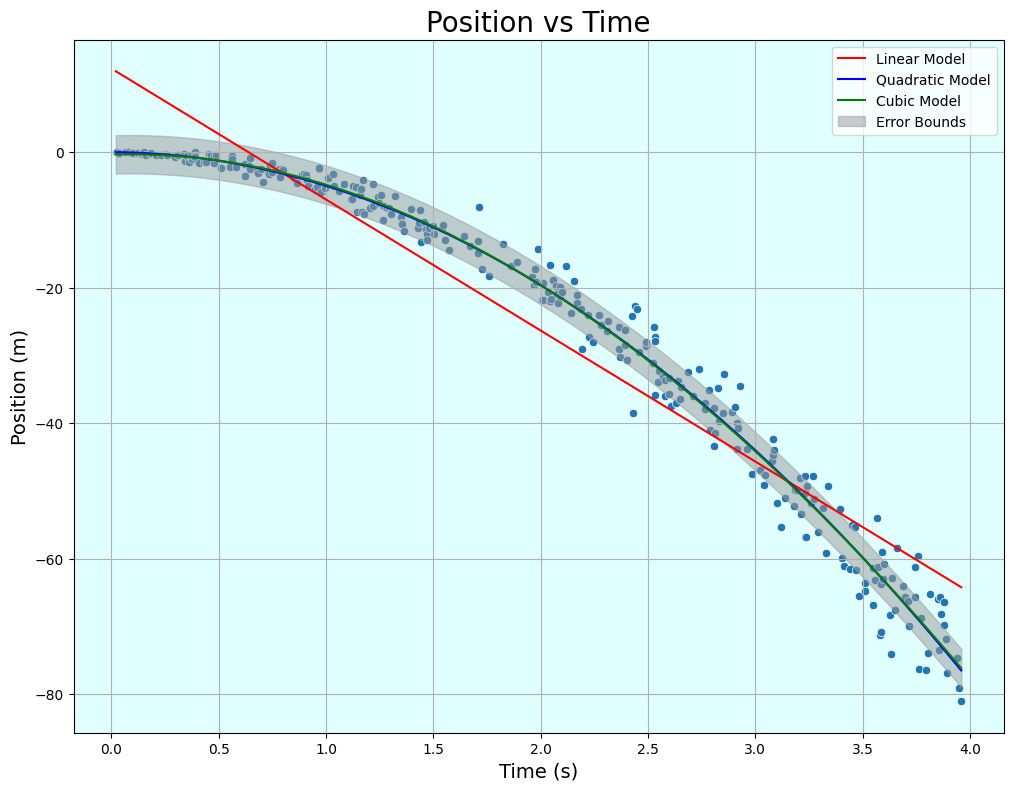

In [ ]:
##=============================================================================================##
## Set the Model Feature(s) and Target:                                                        ##
##=============================================================================================##

X = features.copy()
y = target.copy()

# Add the time squared and time cubed data to the features:

X["Quadratic Time"] = X["Time (s)"] ** 2

X["Cubic"] = X["Time (s)"] ** 3


##=============================================================================================##
## Create the Model and Get the Results and Predictions:                                       ##
##=============================================================================================##

cubic_results, cubic_predictions = create_model(X, y, "Cubic")

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

name_list = [linear_results["Name"][0], quadratic_results["Name"][0],
             cubic_results["Name"][0]]

# Set the coefficient(s) list:

coef_list = [linear_results["Coefs"][0], quadratic_results["Coefs"][0],
             cubic_results["Coefs"][0]]

# Set the bias list:

bias_list = [linear_results["Bias"][0], quadratic_results["Bias"][0],
             cubic_results["Bias"][0]]

# Set the loss list:

loss_list = [linear_results["Loss"][0], quadratic_results["Loss"][0],
             cubic_results["Loss"][0]]

# Display the results:

display_model(name_list, coef_list, bias_list, loss_list, "Models")

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Position vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Position (m)"

# Create the model, color, and label lists:

model_list = [linear_predictions, quadratic_predictions, cubic_predictions]
color_list = ["red", "blue", "green"]
label_list = ["Linear Model", "Quadratic Model", "Cubic Model"]

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X[x_label], y[y_label], title, [x_label, y_label], model_list, color_list,
                  label_list, error_display = True, error = loss_list[-1])

<a name="Quartic-Model"></a>

---

<font size = 6> Quartic Model </font>

---

,Coefficient(s),Bias,Loss
Model,,,
Linear,[-19.33],12.34,6.385
Quadratic,"[-0.12, -4.85]",0.00,2.835
Cubic,"[0.94, -5.51, 0.11]",-0.34,2.832
Quartic,"[-3.37, -0.51, -1.87, 0.25]",0.48,2.817


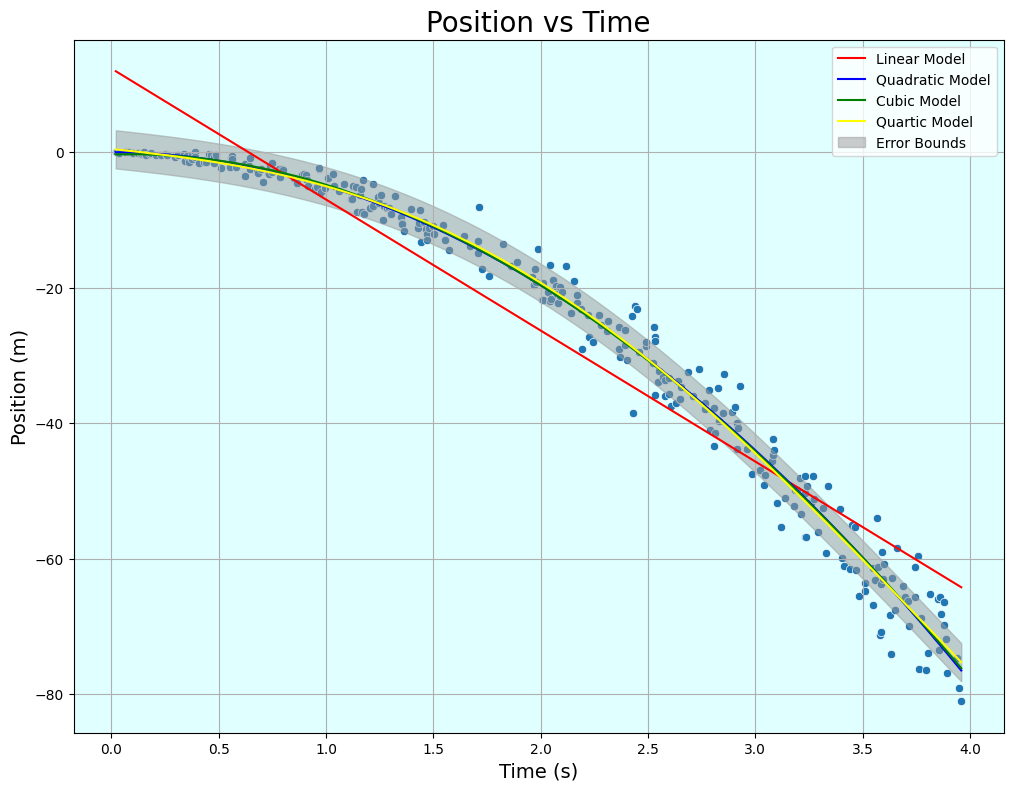

In [ ]:
##=============================================================================================##
## Set the Model Feature(s) and Target:                                                        ##
##=============================================================================================##

X = features.copy()
y = target.copy()

# Add the time squared, time cubed, and time^4 data to the features:

X["Quadratic Time"] = X["Time (s)"] ** 2

X["Cubic Time"] = X["Time (s)"] ** 3

X["Quartic Time"] = X["Time (s)"] ** 4

##=============================================================================================##
## Create the Model and Get the Results and Predictions:                                       ##
##=============================================================================================##

quartic_results, quartic_predictions = create_model(X, y, "Quartic")

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

name_list = [linear_results["Name"][0], quadratic_results["Name"][0],
             cubic_results["Name"][0], quartic_results["Name"][0]]

# Set the coefficient(s) list:

coef_list = [linear_results["Coefs"][0], quadratic_results["Coefs"][0],
             cubic_results["Coefs"][0], quartic_results["Coefs"][0]]

# Set the bias list:

bias_list = [linear_results["Bias"][0], quadratic_results["Bias"][0],
             cubic_results["Bias"][0], quartic_results["Bias"][0]]

# Set the loss list:

loss_list = [linear_results["Loss"][0], quadratic_results["Loss"][0],
             cubic_results["Loss"][0], quartic_results["Loss"][0]]

# Display the results:

display_model(name_list, coef_list, bias_list, loss_list, "Models")

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Position vs Time"

# Set the x-axis and y-axis labels:

x_label = "Time (s)"
y_label = "Position (m)"

# Create the model, color, and label lists:

model_list = [linear_predictions, quadratic_predictions, cubic_predictions, quartic_predictions]
color_list = ["red", "blue", "green", "yellow"]
label_list = ["Linear Model", "Quadratic Model", "Cubic Model", "Quartic Model"]

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X[x_label], y[y_label], title, [x_label, y_label], model_list, color_list,
                  label_list, error_display = True, error = loss_list[-1])

<a name="Introducing-PolynomialFeatures-Transformer"></a>

---

<font size = 6> Introducing PolynomialFeatures Transformer</font>

---

Let's see what happens when we go to even higher order models. And here, by order, I mean the degree of the generated polynomial features where squared features are degree two, cubed features are degree 3, etc.

<br>

We could try this out by manually creating an hp^4 feature, an hp^5 feature, and so forth. However, I'd like us to take a step back and write code that generalizes more easily. Our goal in this section is to create a DataFrame with an hp, hp^2, and hp^3 column, but without having to manually create each column.

<br>

In our new approach, we're going to use a special object in scikit-learn called a transformer. A transformer takes a set of existing features as input and outputs new features. As an example, this code creates a PolynomialFeatures transformer. The constructor for PolynomialFeatures wants to know the degree for the new transformer, which we set to three in this example. The PolynomialFeatures transformer, like all transformers, has a method called fit_transform. It takes the value given and produces a set of input features corresponding to the zeroth, first, second, and third power of the input value. So if the input is 5, it gives me back 1, 5, 25, and 125. In other words, this transformer has automatically generated all the features of degree three from our original value of five.

In [ ]:
##=============================================================================================##
## Test the Polynomial Features Transformer on a Fixed Value (5):                              ##
##=============================================================================================##

# Create a PolynomialFeatures transformer that will produce up to cubic features:

poly_transform = PolynomialFeatures(degree = 3)

# Fit the model and transform the value of '5' to produce its features up to cubic:

transformed_features = poly_transform.fit_transform([[5]])

# Show the transformed features:

display(transformed_features)

array([[  1.,   5.,  25., 125.]])

If we apply this transform function to our entire DataFrame, the result is a large two-dimensional array, with each row corresponding to a sample from our original input DataFrame and each column corresponding to one of the transformed features.

In [ ]:
##=============================================================================================##
## Use PolynomialFeatures Transformer on our Horsepower Data:                                  ##
##=============================================================================================##

# Create a PolynomialFeatures transformer that will produce up to cubic features:

poly_transform = PolynomialFeatures(degree = 3)

# Fit the model and transform the horsepower data to produce its features up to cubic:

transformed_features = poly_transform.fit_transform(features)

# Display the transformed features:

display(transformed_features)

array([[1.00000000e+00, 2.02000000e-02, 4.08040000e-04, 8.24240800e-06],
       [1.00000000e+00, 2.21000000e-02, 4.88410000e-04, 1.07938610e-05],
       [1.00000000e+00, 2.78000000e-02, 7.72840000e-04, 2.14849520e-05],
       ...,
       [1.00000000e+00, 3.94260000e+00, 1.55440948e+01, 6.12841480e+01],
       [1.00000000e+00, 3.94750000e+00, 1.55827562e+01, 6.15129303e+01],
       [1.00000000e+00, 3.96020000e+00, 1.56831840e+01, 6.21085454e+01]])

At this point, we're still getting to our goal, but we have a couple of problems. The first is that the output that we've received is a NumPy array, not a DataFrame. And that's just how transformers work. So to convert our NumPy array provided by the transform into a DataFrame, we simply call pd.DataFrame on the output of the fit transform.

In [ ]:
##=============================================================================================##
## Convert the Transformed Features Into a Pandas DataFrame:                                   ##
##=============================================================================================##

features_df = pd.DataFrame(transformed_features)

display(features_df.head())

,0,1,2,3
0,1.0,0.0202,0.000408,0.000008
1,1.0,0.0221,0.000488,0.000011
2,1.0,0.0278,0.000773,0.000021
3,1.0,0.0368,0.001354,0.000050
4,1.0,0.0618,0.003819,0.000236


We're still not quite there though, because we need to get rid of this extraneous column of all ones on the far left. That leftmost column of all ones is known as a bias feature, which is always equal to one. And if you don't want that bias feature, you can get rid of it by setting `include_bias` to False in the constructor for the PolynomialFeatures object.

In [ ]:
##=============================================================================================##
## Use PolynomialFeatures Transformer on our Horsepower Data Without a Bias:                   ##
##=============================================================================================##

# Create a PolynomialFeatures transformer that will produce up to cubic features:

poly_transform = PolynomialFeatures(degree = 3, include_bias = False)

# Fit the model and transform the horsepower data to produce its features up to cubic:

transformed_features = poly_transform.fit_transform(features)

# Convert the transformed_features array into a DataFrame:

features_df = pd.DataFrame(transformed_features)

# Display the transformed features DataFrame:

display(features_df.head())

,0,1,2
0,0.0202,0.000408,0.000008
1,0.0221,0.000488,0.000011
2,0.0278,0.000773,0.000021
3,0.0368,0.001354,0.000050
4,0.0618,0.003819,0.000236


There's one last thing we need to do, rename the columns horsepower, horsepower^2, and horsepower^3, rather than their current names, 0, 1, and 2. The PolynomialFeatures object has a really cool function called get_feature_names_out that will automatically return all the generated names for features based on the original names that it saw when it carried out the fit transform. In this case, when we ask for those names, we see that it gives us horsepower, horsepower^2, and horsepower^3. By providing these names to the DataFrame constructor using the columns keyword, we get a nice DataFrame with useful column names.

In [ ]:
##=============================================================================================##
## Get the DataFrame Column Names From PolynomialFeatures:                                     ##
##=============================================================================================##

# Get the feature names:

column_names = poly_transform.get_feature_names_out()

print()
print("Column Names:", column_names)
print()

# Rename the DataFrame Columns:

features_df.columns = [column_names]

# Display the updated Dataframe:

display(features_df.head())


Column Names: ['Time (s)' 'Time (s)^2' 'Time (s)^3']



,Time (s),Time (s)^2,Time (s)^3
0,0.0202,0.000408,0.000008
1,0.0221,0.000488,0.000011
2,0.0278,0.000773,0.000021
3,0.0368,0.001354,0.000050
4,0.0618,0.003819,0.000236


We can combine a lot of the work that we just did into just a few lines of code.

In [ ]:
##=============================================================================================##
## Combined Method For Getting the Polynomial Features:                                        ##
##=============================================================================================##

# Create a PolynomialFeatures transformer that will produce up to cubic features:

poly_transform = PolynomialFeatures(degree = 3, include_bias = False)

# Generate the Polynomial Features DataFrame:

features_df = pd.DataFrame(poly_transform.fit_transform(features),
                           columns = poly_transform.get_feature_names_out())

# Display the Features DataFrame:

display(features_df.head())

,Time (s),Time (s)^2,Time (s)^3
0,0.0202,0.000408,0.000008
1,0.0221,0.000488,0.000011
2,0.0278,0.000773,0.000021
3,0.0368,0.001354,0.000050
4,0.0618,0.003819,0.000236


With this new method of generating higher order features, we can produce models with degree 4 or 5 (or 50) by changing a single number.

In [ ]:
##=============================================================================================##
## Use PolynomialFeatures to generate a 5th order model:                                       ##
##=============================================================================================##

# Create a PolynomialFeatures transformer that will produce up to cubic features:

poly_transform = PolynomialFeatures(degree = 5, include_bias = False)

# Generate the Polynomial Features DataFrame:

features_df = pd.DataFrame(poly_transform.fit_transform(features),
                           columns = poly_transform.get_feature_names_out())

# Display the Features DataFrame:

display(features_df.head())

,Time (s),Time (s)^2,Time (s)^3,Time (s)^4,Time (s)^5
0,0.0202,0.000408,0.000008,1.664966e-07,3.363232e-09
1,0.0221,0.000488,0.000011,2.385443e-07,5.271830e-09
2,0.0278,0.000773,0.000021,5.972817e-07,1.660443e-08
3,0.0368,0.001354,0.000050,1.833966e-06,6.748995e-08
4,0.0618,0.003819,0.000236,1.458659e-05,9.014515e-07


test the first 10 polynomial orders.

In [ ]:
##=============================================================================================##
## Use PolynomialFeatures to generate a 10th order model:                                      ##
##=============================================================================================##

# Create a PolynomialFeatures transformer:

poly_transform = PolynomialFeatures(degree = 10, include_bias = False)

# Generate the Polynomial Features DataFrame:

X = pd.DataFrame(poly_transform.fit_transform(features),
                 columns = poly_transform.get_feature_names_out())

##=============================================================================================##
## Create a List of Features:                                                                  ##
##=============================================================================================##

y = target.copy()

X_list = []

# Loop over polynomial orders from 1 to 10:

for i in range(1, 11):

    # Create a PolynomialFeatures transformer:

    poly_transform = PolynomialFeatures(degree = i, include_bias = False)

    # Generate the Polynomial Features DataFrame:

    X_list.append(pd.DataFrame(poly_transform.fit_transform(features),
                               columns = poly_transform.get_feature_names_out()))

##=============================================================================================##
## Create Lists to Hold the Model Results:                                                     ##
##=============================================================================================##

# Create a List of model names based on polynomial order:

model_list = ["Linear", "Quadratic", "Cubic", "Quartic", "Quintic", "Sextic", "Septic",
              "Octic", "Nonic", "Decic"]

# Create a List of coefficients:

coef_list = []

# Create a List of biases:

bias_list = []

# Create a List of losses:

loss_list = []

##=============================================================================================##
## Use a LinearRegression Object to Find the Best Fit for Each Polynomial Model:               ##
##=============================================================================================##

# Create a LinearRegression object with a forced-origin intercept:

model = LinearRegression(fit_intercept = False)

# Loop over polynomial orders from 1 to 10:

for i in range(0, 10):

  # Fit the LinearRegression objects to the features and target:

  model.fit(X_list[i], y)

  # Get the coefficient and bias for the model:

  coef_list.append(np.round(model.coef_[0], 2))
  bias_list.append(np.round(model.intercept_, 2))

  # Get the model's loss:

  model_predictions = model.predict(X_list[i])
  loss_list.append(np.sqrt(mean_squared_error(y, model_predictions)))

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

display_model(model_list, coef_list, bias_list, loss_list, "Polynomial Models")

,Coefficient(s),Bias,Loss
Model,,,
Linear,[-14.72],0.0,8.968
Quadratic,"[-0.12, -4.85]",0.0,2.835
Cubic,"[0.29, -5.19, 0.06]",0.0,2.834
Quartic,"[-1.89, -1.84, -1.42, 0.2]",0.0,2.819
Quintic,"[1.49, -9.76, 4.55, -1.6, 0.19]",0.0,2.806


Overfitting: Overfitting is a type of error that occurs when a model is too closely aligned to a training dataset. Consequently, the model is valid only in relation to its training dataset and not any subsequent dataset. Overfitting is a common problem in machine learning, but it typically can be handled by utilizing the following techniques: holdout (test/train split), cross-validation, feature selection (engineering), and data augmentation.

In [ ]:
#data = pd.concat([features, target], axis = 1)

#training_set, testing_set = train_test_split(data, test_size = 0.2, random_state=10)

#X_train = training_set[["Time (s)"]]

#y_train = training_set[["Position (m)"]]

#X_test = testing_set[["Time (s)"]]

#y_test = testing_set[["Position (m)"]]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=10)

#display(testing_set.tail())

#display(training_set.tail())

In [ ]:
##=============================================================================================##
## Use PolynomialFeatures to generate a 10th order model:                                      ##
##=============================================================================================##

# Create a PolynomialFeatures transformer:

poly_transform = PolynomialFeatures(degree = 10, include_bias = False)

# Generate the Polynomial Features DataFrame:

X = pd.DataFrame(poly_transform.fit_transform(X_train),
                 columns = poly_transform.get_feature_names_out())

##=============================================================================================##
## Create a List of Features:                                                                  ##
##=============================================================================================##

y = y_train.copy()

X_train_list = []
X_test_list = []

# Loop over polynomial orders from 1 to 10:

for i in range(1, 11):

    # Create a PolynomialFeatures transformer:

    poly_transform = PolynomialFeatures(degree = i, include_bias = False)

    # Generate the Polynomial Features DataFrame:

    X_train_list.append(pd.DataFrame(poly_transform.fit_transform(X_train),
                               columns = poly_transform.get_feature_names_out()))

    X_test_list.append(pd.DataFrame(poly_transform.fit_transform(X_test),
                               columns = poly_transform.get_feature_names_out()))

##=============================================================================================##
## Create Lists to Hold the Model Results:                                                     ##
##=============================================================================================##

# Create a List of model names based on polynomial order:

model_list = ["Linear", "Quadratic", "Cubic", "Quartic", "Quintic", "Sextic", "Septic",
              "Octic", "Nonic", "Decic"]

# Create a List of coefficients:

coef_list = []

# Create a List of biases:

bias_list = []

# Create a List of losses:

loss_list = []

##=============================================================================================##
## Use a LinearRegression Object to Find the Best Fit for Each Polynomial Model:               ##
##=============================================================================================##

# Create a LinearRegression object with a forced-origin intercept:

model = LinearRegression(fit_intercept = False)

# Loop over polynomial orders from 1 to 10:

for i in range(0, 10):

  # Fit the LinearRegression objects to the features and target:

  model.fit(X_train_list[i], y)

  # Get the coefficient and bias for the model:

  coef_list.append(np.round(model.coef_[0], 2))
  bias_list.append(np.round(model.intercept_, 2))

  # Get the model's loss:

  model_predictions = model.predict(X_test_list[i])
  loss_list.append(np.sqrt(mean_squared_error(y_test, model_predictions)))

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

display_model(model_list, coef_list, bias_list, loss_list, "Polynomial Models")

,Coefficient(s),Bias,Loss
Model,,,
Linear,[-14.64],0.0,9.822
Quadratic,"[-0.27, -4.8]",0.0,3.385
Cubic,"[0.36, -5.33, 0.1]",0.0,3.395
Quartic,"[-2.51, -0.92, -1.86, 0.26]",0.0,3.427
Quintic,"[1.69, -10.8, 5.61, -1.99, 0.24]",0.0,3.444


<a name="Introducing-Pipelines"></a>

---

<font size = 6> Introducing Pipelines </font>

---

So we have these two workarounds to use our cubic model. Both still feel unnecessarily verbose. Luckily, there is a better way. The next approach is oh, so gloriously elegant. Now we are going to learn how to use an sklearn pipeline. A scikit-learn pipeline lets you set up a sequence of useful data processing tasks that will be done sequentially. In the code below is a two-stage pipeline. Each stage of the pipeline has a name, which is just some arbitrary name that you pick as a programmer. If we wish, we can access the individual steps of the pipeline by calling these names.

<br>

* The first stage is a PolynomialFeatures generator which we've named `transform`. You'll observe that this transformer is just our cubic polynomial transformer from before.

* the second stage is a LinearRegression model which we've named `regression`. This stage is just a standard linear regression model.

In [ ]:
# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=10)

# Step 2: Create a pipeline
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(include_bias = False, degree = 2)),
    ('lin_reg', LinearRegression(fit_intercept = False))
])

# Step 3: Fit pipeline on training data
pipeline.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred = pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Root Mean Squared Error on Test Set: {rmse:.3f}")

Root Mean Squared Error on Test Set: 3.385


In [ ]:
##=============================================================================================##
## Create a Data Pipeline:                                                                     ##
##=============================================================================================##

# Create the pipeline:

pipelined_model = Pipeline([('transform', PolynomialFeatures(degree = 2, include_bias = False)),
                            ('regression', LinearRegression(fit_intercept = False))])


# Display the first stage of the pipeline:

print()
print("Pipeline Stage 1 ('transform'): ")
print()

display(pipelined_model['transform'])

# Display the second stage of the pipeline:

print()
print("Pipeline Stage 2 ('regression'): ")
print()

display(pipelined_model['regression'])


Pipeline Stage 1 ('transform'): 



PolynomialFeatures(include_bias=False)


Pipeline Stage 2 ('regression'): 



LinearRegression(fit_intercept=False)

Now we can fit our pipeline using feature and target data. For the feature, we will use the `horsepower` column of the data.

* The feature data is passed to the `transform` stage, where the PolynomialFeatures object transformes it into polynomial feature data.

* The polynomial feature data is then passed along with the target data to the second stage where the LinearRegression object is fit.

In [ ]:
##=============================================================================================##
## Fit the Data Pipeline:                                                                      ##
##=============================================================================================##

# Fit the data pipeline:

pipelined_model.fit(features, target)

Pipeline(steps=[('transform', PolynomialFeatures(include_bias=False)),
                ('regression', LinearRegression(fit_intercept=False))])

This approach has a few advantages. Most notably, we can apply this model to new data directly. We could just say, pipeline model, please predict the results for a 100 horsepower engine. It will do so without the need to somehow generate the squared and cubic features ourselves. Another nice advantage is that we don't need to explicitly create a new DataFrame of new features when we're training the model. Lastly, we don't have to keep track of separate transformer and regression objects that end up floating around in the variable scope of our Notebooks.

<br>

Now, we can use the pipeline object to make predictions.

In [ ]:
##=============================================================================================##
## Fourth Attempt to Predict the Gas Mileage:                                                  ##
##=============================================================================================##

# Make the predction of the falling object's position given a specfic time:

t_05 = pd.DataFrame({"Time (s)": [1.5]})

pos_05 = pipelined_model.predict(t_05)[0][0]

# Print the prediction:

print()
print("Predicted Position:", np.round(pos_05, 3))


Predicted Position: -11.081


Let's say that we wanted to extract information from a specific step of the pipeline. For example, we might want to get the coefficients and intercept from the regression step. We can access that information by calling the name that we gave that step of the pipeline.

In [ ]:
##=============================================================================================##
## Extract Information From the Pipeline:                                                      ##
##=============================================================================================##

# Get the coefficients from the LinearRegression object:

coef = pipelined_model['regression'].coef_

# Get the intercept from the LinearRegression object:

bias = pipelined_model['regression'].intercept_

# Print the regression model's coefficients and intercept:

print()
print("Model Coefficients:", np.round(coef, 3))
print()
print("Model Intercept:", np.round(bias, 3))


Model Coefficients: [[-0.116 -4.848]]

Model Intercept: 0.0


<a name="Polynomial-Models-Orders-1-6"></a>

---

<font size = 6> Put it all together </font>

---

In [ ]:
##=============================================================================================##
## Prepare the Data For Modeling and Cross-Verification:                                       ##
##=============================================================================================##

# Set the data features and target:

X = features.copy()

y = target.copy()

# Separate the training and testing data:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

##=============================================================================================##
## Create a Data Pipeline to Transform the Data and Perform Linear Regression:                 ##
##=============================================================================================##

from sklearn.preprocessing import StandardScaler

pipe = Pipeline([('transform',  PolynomialFeatures(degree = 2, include_bias = False)),
                 ('regression', LinearRegression(fit_intercept = False))])

##=============================================================================================##
## Fit the Pipeline to the Training Data:                                                      ##
##=============================================================================================##

pipe.fit(X_train, y_train)

##=============================================================================================##
## Perform Cross-Validation of the Model:                                                      ##
##=============================================================================================##

# Get the model's predictions:

y_pred = pipe.predict(X_test)

# Compute the RMSE Loss:

loss = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error on Test Set:", np.round(loss, 3))

Root Mean Squared Error on Test Set: 3.385
